In [ ]:
%pip install torch_geometric
%pip install ogb
%pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.4.0+cu121.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 2.6 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.4.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 986.2/986.2 kB 7.6 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, Reddit
from torch_geometric.nn import GCNConv
from torch_geometric.loader import ClusterData, ClusterLoader
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import time
from torch_geometric.datasets import WikipediaNetwork
from sklearn.model_selection import train_test_split
from torch_geometric.typing import Adj, SparseTensor
from torch_geometric.datasets import Reddit, Reddit2, Flickr, Yelp, AmazonProducts, PPI,  OGB_MAG,  FakeDataset, Amazon
from ogb.nodeproppred import Evaluator, PygNodePropPredDataset
from torch_geometric.utils import scatter
from torch_geometric.datasets import Reddit, Reddit2, Flickr, Yelp, AmazonProducts, PPI,  OGB_MAG,  FakeDataset, Amazon,Coauthor,HeterophilousGraphDataset

In [ ]:


def load_dataset(dataset_name):
    if dataset_name == "Cora":
        dataset = Planetoid(root='/tmp/Cora', name='Cora')
    elif dataset_name == "Reddit":
        dataset = Reddit(root='/tmp/Reddit')
    elif dataset_name == 'penn94':
        from torch_geometric.datasets import LINKXDataset
        dataset = LINKXDataset(root='/tmp/LINKX', name=dataset_name)
    elif dataset_name == 'wiki':
        from torch_geometric.datasets import WikiCS
        dataset = WikiCS(root='/tmp/WikiCS')
    elif dataset_name == 'Photo':
        dataset = Amazon(root='/tmp/Photo', name='Photo')
    elif dataset_name == 'CiteSeer':
      dataset = Planetoid(root='/tmp/CiteSeer', name=DATASET_NAME)
    elif dataset_name == 'CS':
      dataset = Coauthor(root='/tmp/CS', name = DATASET_NAME)
    elif dataset_name == 'Physics':
      dataset = Coauthor(root='/tmp/Physics', name = DATASET_NAME)
    elif dataset_name == 'Minesweeper':
      dataset   = HeterophilousGraphDataset(root='/tmp/Mine',name=dataset_name)
    elif dataset_name == 'pokec':
      print("HELLOWROLD ")
    elif dataset_name == 'ogbn-proteins':
        dataset = PygNodePropPredDataset(name='ogbn-proteins', root='/tmp/ogbn-proteins')
        data = dataset[0]
        data.node_species = None
        data.y = data.y.to(torch.float)

        # Initialize features of nodes by aggregating edge features.
        row, col = data.edge_index
        data.x = scatter(data.edge_attr, col, dim_size=data.num_nodes, reduce='sum')
        labels = data.y.argmax(dim=1)
        data.y = labels
        return dataset, data
    elif dataset_name == 'squirrel':
        dataset = WikipediaNetwork(root='/tmp/squirrel', name='Squirrel')
    elif dataset_name == 'AmazonProducts':
        dataset = AmazonProducts(root='/tmp/AmazonProducts')
    else:
        dataset = Planetoid(root='/tmp/Cora', name='Cora')

    print(dataset)
    data = dataset[0]
    print(data)
    return dataset, data

# Example usage:
dataset_name = "Minesweeper"
DATASET_NAME = dataset_name
dataset, data = load_dataset(dataset_name)

HeterophilousGraphDataset(name=minesweeper)
Data(x=[10000, 7], edge_index=[2, 78804], y=[10000], train_mask=[10000, 10], val_mask=[10000, 10], test_mask=[10000, 10])


In [ ]:
dataset_name = 'Roman-empire'
DATASET_NAME = dataset_name
dataset   = HeterophilousGraphDataset(root='/tmp/roman',name=dataset_name)
data = dataset[0]
print(data)

Data(x=[22662, 300], edge_index=[2, 65854], y=[22662], train_mask=[22662, 10], val_mask=[22662, 10], test_mask=[22662, 10])


In [ ]:
split_index = 0
data.train_mask = data.train_mask[:,split_index]
data.val_mask = data.val_mask[:,split_index]
data.test_mask = data.test_mask[:,split_index]

print(data.train_mask)
print(data.val_mask)
print(data.test_mask)

tensor([False, False, False,  ...,  True, False,  True])
tensor([False, False, False,  ..., False,  True, False])
tensor([ True,  True,  True,  ..., False, False, False])


In [ ]:
def train_val_test_mask(data, train=0.6, val=0.2, test=0.2, random_state=False):

    if isinstance(data.x, SparseTensor):
        N = data.x.size(0)
        data.num_nodes = N
    else:
        N = data.x.shape[0]

    indexs = list(range(N))

    if random_state:
        train_index, test_index = train_test_split(indexs, test_size=val+test)
        val_index, test_index = train_test_split(test_index, test_size=test/(val+test))
    else:
        train_index, test_index = train_test_split(indexs, test_size=val+test, random_state=1)
        val_index, test_index = train_test_split(test_index, test_size=test/(val+test), random_state=1)



    train_mask = torch.zeros(N, dtype=bool)
    train_mask[train_index]=True
    val_mask = torch.zeros(N, dtype=bool)
    val_mask[val_index]=True
    test_mask = torch.zeros(N, dtype=bool)
    test_mask[test_index]=True

    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask

    return data

In [ ]:
data = train_val_test_mask(data)
data

Data(num_nodes=132534, edge_index=[2, 79122504], edge_attr=[79122504, 8], y=[132534, 112], x=[132534, 8], train_mask=[132534], val_mask=[132534], test_mask=[132534])

In [ ]:
# Define the MLP for edge probability
class EdgeProbMLP(nn.Module):
    def __init__(self, in_channels, hidden_dim):
        super(EdgeProbMLP, self).__init__()
        self.fc1 = nn.Linear(2 * in_channels, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, node_features, edge_index):
        edge_features = torch.cat([node_features[edge_index[0]], node_features[edge_index[1]]], dim=1)
        x = F.relu(self.fc1(edge_features))
        prob = torch.sigmoid(self.fc2(x))
        return prob

# Define the overall model with Edge Probabilities and GCNConv (GNN)
class GNNModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes):
        super(GNNModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim)
        self.gcn1 = GCNConv(in_channels, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, num_classes)

    def forward(self, data, edge_index):
        # Forward pass through two layers of GCNConv with the given edges
        x = F.relu(self.gcn1(data.x, edge_index))
        out = self.gcn2(x, edge_index)
        return out

# Gumbel-Softmax trick for edge sampling
def gumbel_softmax_sampling(edge_probs, edge_index, q=500):
    gumbels = -torch.empty_like(edge_probs).exponential_().log()  # Sample from Gumbel(0, 1)
    logits = (edge_probs + gumbels) / 0.5  # Temperature parameter tau=0.5
    samples = F.softmax(logits, dim=-1)
    sampled_edges = torch.multinomial(samples, q, replacement=False)
    return sampled_edges

# F1 score calculation helper
def calculate_f1(logits, labels, mask):
    preds = logits[mask].argmax(dim=1)
    f1 = f1_score(labels[mask].cpu(), preds.cpu(), average='micro')
    return f1

# Training function (uses sampled edges)
def train(model, optimizer, criterion, cluster_loader, device, q=500):
    model.train()
    total_loss = 0

    for batch in cluster_loader:
        if not batch.train_mask.any():
          continue

        batch = batch.to(device)
        optimizer.zero_grad()

        # Compute edge probabilities
        edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()

        if batch.edge_index.shape[1]>q:
          # Sample edges using the Gumbel-Softmax trick
          sampled_edge_indices = gumbel_softmax_sampling(edge_probs, batch.edge_index, q=q)
          sampled_edge_index = batch.edge_index[:, sampled_edge_indices]

          # Forward pass with sampled edges
          out = model(batch, sampled_edge_index)
        else:
          out = model(batch, batch.edge_index)

        # Compute node classification loss
        loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])

        # Backpropagate loss
        loss.backward()

        # Accumulate gradients and update parameters
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(cluster_loader)

def evaluate(model, cluster_loader, device):
    model.eval()
    total_train_f1, total_val_f1, total_test_f1 = 0, 0, 0
    num_train_examples, num_val_examples, num_test_examples = 0, 0, 0

    with torch.no_grad():
        for batch in cluster_loader:
            batch = batch.to(device)
            # Use the full graph's edge_index for evaluation (no sampling)
            out = model(batch, batch.edge_index)

            # Calculate F1 scores for train, val, and test sets if masks are present
            if batch.train_mask.any():
                train_f1 = calculate_f1(out, batch.y, batch.train_mask)
                total_train_f1 += train_f1 * batch.train_mask.sum().item()
                num_train_examples += batch.train_mask.sum().item()

            if batch.val_mask.any():
                val_f1 = calculate_f1(out, batch.y, batch.val_mask)
                total_val_f1 += val_f1 * batch.val_mask.sum().item()
                num_val_examples += batch.val_mask.sum().item()

            if batch.test_mask.any():
                test_f1 = calculate_f1(out, batch.y, batch.test_mask)
                total_test_f1 += test_f1 * batch.test_mask.sum().item()
                num_test_examples += batch.test_mask.sum().item()

    avg_train_f1 = total_train_f1 / num_train_examples if num_train_examples > 0 else 0
    avg_val_f1 = total_val_f1 / num_val_examples if num_val_examples > 0 else 0
    avg_test_f1 = total_test_f1 / num_test_examples if num_test_examples > 0 else 0

    return avg_train_f1, avg_val_f1, avg_test_f1


# # Main training loop
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = GNNModel(in_channels=dataset.num_node_features, hidden_dim=128, out_channels=64, num_classes=dataset.num_classes).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# criterion = nn.CrossEntropyLoss()

# # Create ClusterData and ClusterLoader
# num_edges_per_partition = 5000
# sample_size = 1000
# num_parts = int(data.edge_index.shape[1]/num_edges_per_partition); #num_parts=150
# print("num_parts:", num_parts, "avg edges per pertition: ", int(data.edge_index.shape[1]/num_parts), "sample")

# cluster_data = ClusterData(data, num_parts=num_parts)
# cluster_loader = ClusterLoader(cluster_data, batch_size=1, shuffle=True)

# for epoch in range(200):
#     loss = train(model, optimizer, criterion, cluster_loader, device, q=sample_size)
#     train_f1, val_f1, test_f1 = evaluate(model, cluster_loader, device)

#     print(f'Epoch {epoch}, Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')


In [ ]:
# @title Main

In [ ]:
30000
100000

78804

In [ ]:
# Main training loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GNNModel(in_channels=dataset.num_node_features, hidden_dim=128, out_channels=64, num_classes=dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# Create ClusterData and ClusterLoader
num_edges_per_partition = 30000
sample_size = 5000
num_parts = int(data.edge_index.shape[1]/num_edges_per_partition); #num_parts=150
# num_parts = 1600


print("num_parts:", num_parts, "avg edges per pertition: ", int(data.edge_index.shape[1]/num_parts), "sample size:", sample_size)


start = time.time()
cluster_data = ClusterData(data, num_parts=num_parts, recursive = False, save_dir = 'tmp/'+DATASET_NAME, filename=None,
            log = True, keep_inter_cluster_edges = True)

print("Metis Partition time: ", time.time()-start)

cluster_loader = ClusterLoader(cluster_data, batch_size=1, shuffle=True)

num_parts: 2 avg edges per pertition:  32927 sample size: 5000
Metis Partition time:  0.058541297912597656


Computing METIS partitioning...
Done!


Epoch 0, Loss: 2.8242, Train F1: 0.1591, Val F1: 0.1569, Test F1: 0.1564
Epoch 1, Loss: 2.5159, Train F1: 0.1708, Val F1: 0.1733, Test F1: 0.1684
Epoch 2, Loss: 2.3406, Train F1: 0.2203, Val F1: 0.2210, Test F1: 0.2233
Epoch 3, Loss: 2.2309, Train F1: 0.2470, Val F1: 0.2478, Test F1: 0.2483
Epoch 4, Loss: 2.1423, Train F1: 0.2958, Val F1: 0.2937, Test F1: 0.2940
Epoch 5, Loss: 2.0831, Train F1: 0.2964, Val F1: 0.2967, Test F1: 0.2972
Epoch 6, Loss: 2.0202, Train F1: 0.2874, Val F1: 0.2920, Test F1: 0.2866
Epoch 7, Loss: 1.9647, Train F1: 0.2822, Val F1: 0.2810, Test F1: 0.2778
Epoch 8, Loss: 1.9357, Train F1: 0.3052, Val F1: 0.3064, Test F1: 0.3018
Epoch 9, Loss: 1.8999, Train F1: 0.3137, Val F1: 0.3133, Test F1: 0.3131
Epoch 10, Loss: 1.8722, Train F1: 0.3113, Val F1: 0.3064, Test F1: 0.3110
Epoch 11, Loss: 1.8519, Train F1: 0.2976, Val F1: 0.2932, Test F1: 0.2930
Epoch 12, Loss: 1.8311, Train F1: 0.2929, Val F1: 0.2884, Test F1: 0.2893
Epoch 13, Loss: 1.8071, Train F1: 0.3127, Val F1

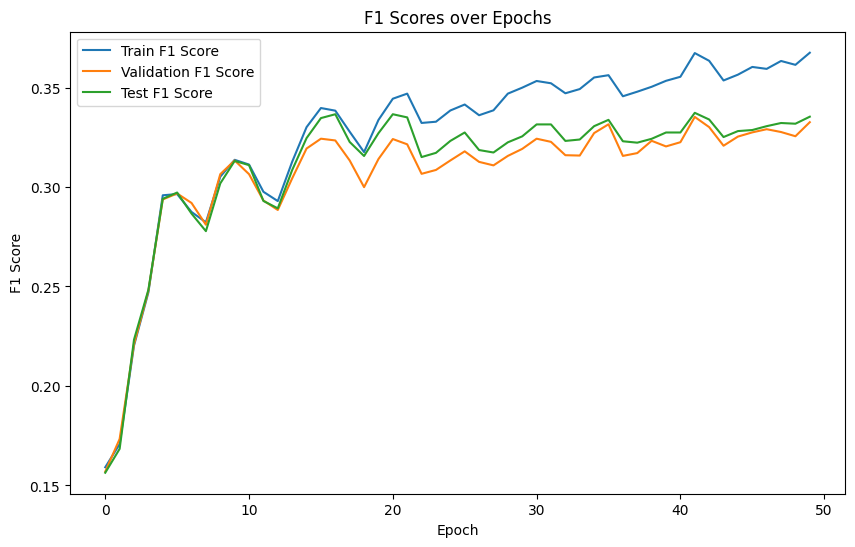

In [ ]:
NUM_EPOCHS = 50

train_f1_scores = np.zeros(NUM_EPOCHS)
val_f1_scores = np.zeros(NUM_EPOCHS)
test_f1_scores = np.zeros(NUM_EPOCHS)

best_test_f1 = 0

for epoch in range(NUM_EPOCHS):
    loss = train(model, optimizer, criterion, cluster_loader, device, q=sample_size)
    train_f1, val_f1, test_f1 = evaluate(model, cluster_loader, device)

    # Store the F1 scores
    train_f1_scores[epoch] = train_f1
    val_f1_scores[epoch] = val_f1
    test_f1_scores[epoch] = test_f1

    # Update the best test F1 score
    if test_f1 > best_test_f1:
        best_test_f1 = test_f1

    print(f'Epoch {epoch}, Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')

# Print the best test F1 score
print(f'Best Test F1 Score: {best_test_f1:.4f}')

# Plot the F1 scores
plt.figure(figsize=(10, 6))
plt.plot(train_f1_scores, label='Train F1 Score')
plt.plot(val_f1_scores, label='Validation F1 Score')
plt.plot(test_f1_scores, label='Test F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Scores over Epochs')
plt.legend()
plt.show()

In [ ]:
a = [0.6967,0.6909,0.6876,0.6948,0.6889]
mean_a = np.mean(a)
std_dev_a = np.std(a)
print(mean_a,std_dev_a)